In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

In [3]:
fontsize=18

In [4]:
def read_data(sim_dir):
    sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")

    mhalo_sim1 = sim_data1[:,0]
    sfr_sim1 = sim_data1[:,4]

    sim_data2 = np.loadtxt(f"{sim_dir}/sfr-cent_0sfr.txt")

    mhalo_sim2 = sim_data2[:,0]
    sfr_sim2 = sim_data2[:,4]

    mhalo_sim3 = np.concatenate((mhalo_sim1,np.round(mhalo_sim2,4)))
    sfr_sim3 = np.concatenate((sfr_sim1,sfr_sim2))
    return mhalo_sim3, sfr_sim3

In [5]:
snapnum = 40

In [6]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos",  "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
mhalo_tng = np.log10(halos["Group_M_TopHat200"]*1e10)
sfr_tng = np.log10(halos["GroupSFR"])
mask = (mhalo_tng > 0) #(sfr_tng > -5) & 
mhalo_tng = mhalo_tng[mask]
sfr_tng = sfr_tng[mask]

/tmp/ipykernel_800274/3429083201.py:1: RuntimeWarning: divide by zero encountered in log10
  mhalo_tng = np.log10(halos["Group_M_TopHat200"]*1e10)
/tmp/ipykernel_800274/3429083201.py:2: RuntimeWarning: divide by zero encountered in log10
  sfr_tng = np.log10(halos["GroupSFR"])


In [9]:
eagle_dir = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17/sfr-group-eagle.txt"
data = np.loadtxt(eagle_dir)
mhalo_eagle = data[:,1]
sfr_eagle = data[:,5]
mask = (mhalo_eagle > 0)#(sfr_eagle > -5) & 
mhalo_eagle = mhalo_eagle[mask]
sfr_eagle = sfr_eagle[mask]

In [26]:
eagle_dir = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17/wo_pos/cent_sfrs.txt"
data = np.loadtxt(eagle_dir)
mhalo_eagle = data[:,1]
sfr_eagle = data[:,2]
mask = (sfr_eagle > -5) & (mhalo_eagle > 0)
# mhalo_eagle = mhalo_eagle[mask]
# sfr_eagle = sfr_eagle[mask]

Running median

In [11]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata))/dx)
    
    
    bin_first = min(xdata) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.percentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [12]:
def running_fraction(xdata, ydata, window_size, lower_lim = -3, dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata))/dx)
    
    bin_first = min(xdata) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    running_frac_arr = np.zeros_like(bins, dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        lim_mask = ydata[bin_mask] < lower_lim
        if i < window_size - 1:
            running_frac_arr[i] = np.nan  # Not enough data points for the window
        else:   
            running_frac_arr[i] = np.sum(lim_mask)/np.sum(bin_mask)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_frac_arr



In [13]:
percentiles_list = [10, 25, 50, 75, 90]
window_size=0.2
dlogM= 0.1

In [14]:
bin_cents_tng, percentiles_tng = running_percentiles(mhalo_tng, sfr_tng, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [27]:
bin_cents_eagle, percentiles_eagle = running_percentiles(mhalo_eagle, sfr_eagle, window_size, percentiles=percentiles_list, dx=dlogM)


In [16]:
color_list_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [17]:
color_list = ["blue", color_list_default[1], "darkorchid"]

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_800274/3667551989.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


(7.6196278213653565, 13.945730103744507)

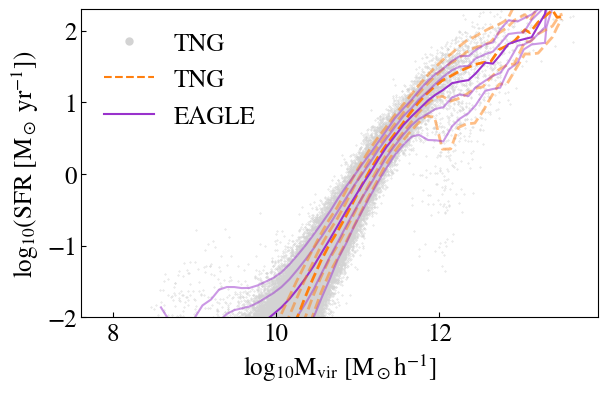

In [18]:
plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.1, color="lightgrey", label="TNG")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="TNG")
tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng_scatter, tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2,2.3)
plt.xlim()


In [28]:
bin_cents_frac_tng, tng_frac = running_fraction(mhalo_tng, sfr_tng, window_size,lower_lim = -2, dx=dlogM)

In [29]:
bin_cents_frac_eagle, eagle_frac = running_fraction(mhalo_eagle, sfr_eagle, window_size,lower_lim = -2, dx=dlogM)

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_800274/4100987664.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


(8.8, 13.7)

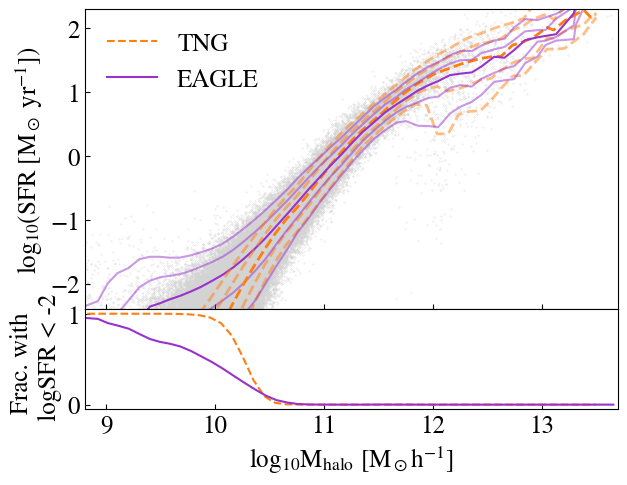

In [ ]:

figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))
tng_scatter = plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.05, color="lightgrey", label="TNG")

for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth=2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2.4,2.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_tng, tng_frac, color=color_list[1], label="TNG", linestyle="dashed")
plt.plot(bin_cents_frac_eagle, eagle_frac, color=color_list[2], label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Frac. with \n logSFR < -2")
plt.xlim(8.8, 13.7)

#plt.savefig("../figures/tng_eagle_percentiles_100.png", format="png", bbox_inches="tight", dpi=300)

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_800274/2158670904.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


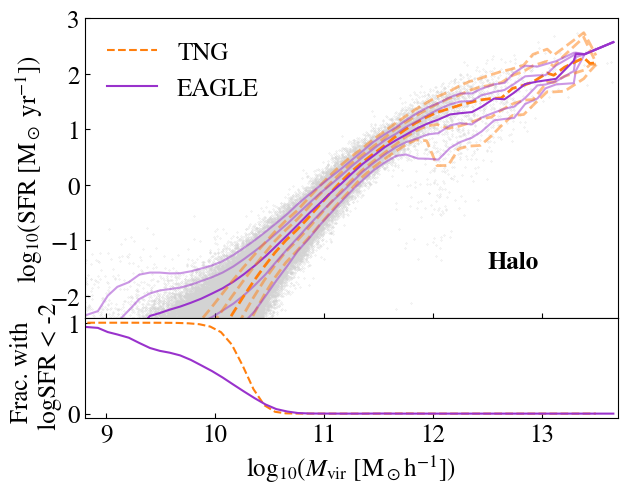

In [24]:

figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))
tng_scatter = plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.05, color="lightgrey", label="TNG")

for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth=2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2.4,3)

ax = plt.gca()
ax.annotate(f"Halo", (12.5,-1.5), weight="bold") 

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_tng, tng_frac, color=color_list[1], label="TNG", linestyle="dashed")
plt.plot(bin_cents_frac_eagle, eagle_frac, color=color_list[2], label="EAGLE")
plt.xlabel(r"log$_{10} (M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
plt.ylabel("Frac. with \n logSFR < -2")
plt.xlim(8.8, 13.7)



plt.savefig("../figures/tng_eagle_percentiles_100_halo.png", format="png", bbox_inches="tight", dpi=300)

In [31]:
def read_data(sim_dir):
    sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")

    mhalo_sim1 = sim_data1[:,0]
    sfr_sim1 = sim_data1[:,4]

    sim_data2 = np.loadtxt(f"{sim_dir}/sfr-cent_0sfr.txt")

    mhalo_sim2 = sim_data2[:,0]
    sfr_sim2 = sim_data2[:,4]

    mhalo_sim3 = np.concatenate((mhalo_sim1,np.round(mhalo_sim2,4)))
    sfr_sim3 = np.concatenate((sfr_sim1,sfr_sim2))
    return mhalo_sim3, sfr_sim3

In [32]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/tng100-1/snap40"
mhalo_tng, sfr_tng = read_data(tng_dir)


In [33]:
eagle_dir = "/cosma7/data/dp004/dc-zhan5/eagle-sfr"
mhalo_eagle, sfr_eagle = read_data(eagle_dir)

In [34]:
bin_cents_tng, percentiles_tng = running_percentiles(mhalo_tng, sfr_tng, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [35]:
bin_cents_eagle, percentiles_eagle = running_percentiles(mhalo_eagle, sfr_eagle, window_size, percentiles=percentiles_list, dx=dlogM)


In [37]:
bin_cents_frac_tng, tng_frac = running_fraction(mhalo_tng, sfr_tng, window_size,lower_lim = -2, dx=dlogM)

In [38]:
bin_cents_frac_eagle, eagle_frac = running_fraction(mhalo_eagle, sfr_eagle, window_size,lower_lim = -2, dx=dlogM)

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_800274/2589677192.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


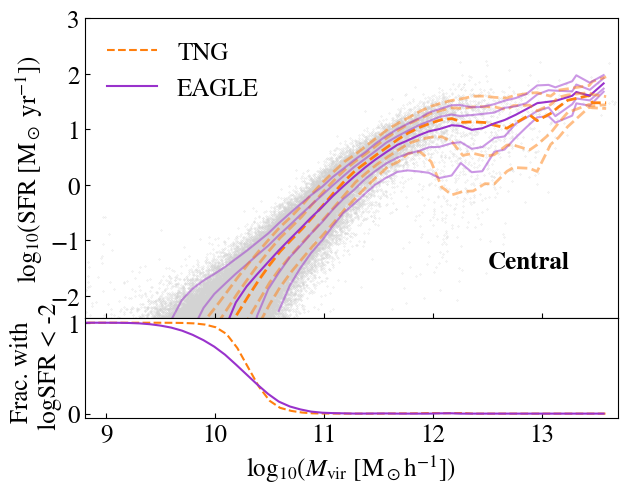

In [40]:

figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))
tng_scatter = plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.05, color="lightgrey", label="TNG")

for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth=2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2.4,3)

ax = plt.gca()
ax.annotate(f"Central", (12.5,-1.5), weight="bold") 

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_tng, tng_frac, color=color_list[1], label="TNG", linestyle="dashed")
plt.plot(bin_cents_frac_eagle, eagle_frac, color=color_list[2], label="EAGLE")
plt.xlabel(r"log$_{10} (M_{\rm vir}$ [M$_\odot$h$^{-1}$])")
plt.ylabel("Frac. with \n logSFR < -2")
plt.xlim(8.8, 13.7)



plt.savefig("../figures/tng_eagle_percentiles_100_cent.png", format="png", bbox_inches="tight", dpi=300)